In [1]:
#%pip install azure-identity azure-storage-blob pandas
#%pip install scikit-learn seaborn matplotlib

## Load Data

In [7]:
import pandas as pd
import json
from io import BytesIO
from azure.identity import DefaultAzureCredential
from azure.storage.blob import BlobServiceClient

from datetime import datetime

# --- 1. ENTERPRISE CONFIGURATION ---
ACCOUNT_URL = "https://rawtradingdata26.blob.core.windows.net"
CONTAINER_NAME = "raw-market-data"

# Dynamically generate today's date string (e.g., '20260401')
today_str = datetime.now().strftime('%Y%m%d')

# Inject the date into the filenames
MARKET_BLOB_NAME = f"market_data_{today_str}.csv"
MACRO_BLOB_NAME = f"macro_data_{today_str}.json"

# Authenticate securely using the workspace's Managed Identity
print("Authenticating with Azure Managed Identity...")
credential = DefaultAzureCredential()
blob_service_client = BlobServiceClient(account_url=ACCOUNT_URL, credential=credential)
container_client = blob_service_client.get_container_client(CONTAINER_NAME)

# --- 2. LOAD MARKET DATA (CSV) ---
print("Downloading Market Data securely...")
market_blob_client = container_client.get_blob_client(MARKET_BLOB_NAME)
market_download = market_blob_client.download_blob().readall()

df_market = pd.read_csv(BytesIO(market_download), header=[0, 1], index_col=0, parse_dates=True)
print(f"Market Data Loaded: {df_market.shape}")

# --- 3. LOAD MACRO DATA (JSON) ---
print("Downloading Macro Data securely...")
macro_blob_client = container_client.get_blob_client(MACRO_BLOB_NAME)
macro_download = macro_blob_client.download_blob().readall()

macro_json = json.loads(macro_download)
df_macro = pd.DataFrame(macro_json['observations'])

df_macro['date'] = pd.to_datetime(df_macro['date'])
df_macro['value'] = pd.to_numeric(df_macro['value'], errors='coerce')
df_macro = df_macro[['date', 'value']].rename(columns={'value': 'CPI'}).set_index('date')
print(f"Macro Data Loaded: {df_macro.shape}")

# Verify the data
print(df_market.head())

Authenticating with Azure Managed Identity...
Market Data Loaded: (2515, 36)
Macro Data Loaded: (950, 1)
Price      Adj Close       Close                                       \
Ticker           XLE         SPY XLE        XLF        XLK        XLU   
Date                                                                    
2016-03-31       NaN  174.607651 NaN  15.161464  19.893051  18.048145   
2016-04-01       NaN  175.797028 NaN  15.296232  20.045523  18.117254   
2016-04-04       NaN  175.227844 NaN  15.222107  19.969280  18.040867   
2016-04-05       NaN  173.477707 NaN  15.006484  19.776443  17.702599   
2016-04-06       NaN  175.372314 NaN  15.087342  19.969280  17.680775   

Price                                   High      ...       Open             \
Ticker            XLV        XLY         SPY XLE  ...        XLU        XLV   
Date                                              ...                         
2016-03-31  57.355076  35.589058  175.363785 NaN  ...  17.968126  57.4481

## Clean, Align, Scaling and Clustering

Cleaned ML Dataset Shape: (2431, 39)


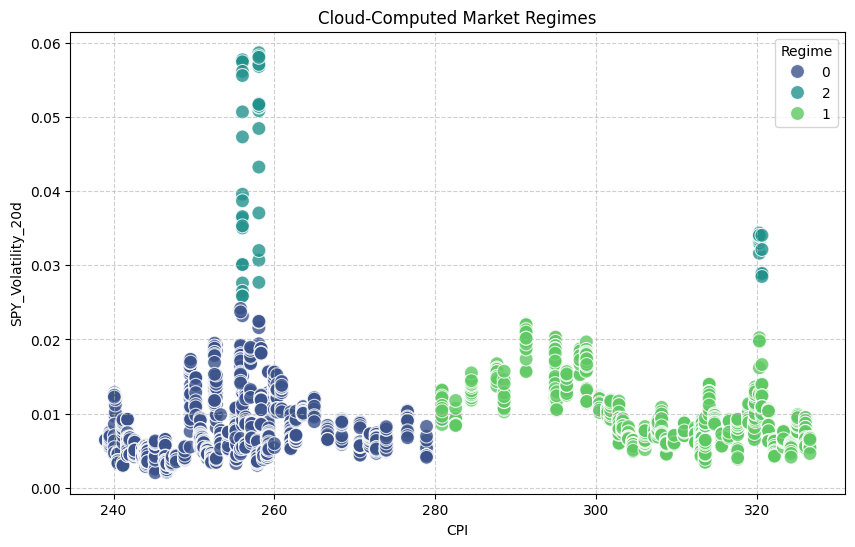


--- Cloud Cluster Averages ---
        SPY_Daily_Return  SPY_Volatility_20d         CPI
Regime                                                  
0               0.000697            0.007774  254.067609
1               0.000373            0.009797  307.516986
2               0.002802            0.040453  279.220386


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CLEAN & ALIGN ---
# THE FIX: Only flatten if it's a MultiIndex (prevents the double-run notebook bug!)
if isinstance(df_market.columns, pd.MultiIndex):
    df_market.columns = [f"{col[0]}_{col[1]}" for col in df_market.columns.values]

# Patch any random missing days in the Yahoo Finance data
df_market = df_market.ffill()

# Strip timezones from the market data index so it matches the macro data
if df_market.index.tz is not None:
    df_market.index = df_market.index.tz_localize(None)

# Expand the monthly CPI data to every single calendar day BEFORE joining
df_macro_daily = df_macro.resample('D').ffill()

# Now perform the join safely
df_merged = df_market.join(df_macro_daily, how='left')

# --- 2. FEATURE ENGINEERING ---
df_merged['SPY_Daily_Return'] = df_merged['Close_SPY'].pct_change()
df_merged['SPY_Volatility_20d'] = df_merged['SPY_Daily_Return'].rolling(window=20).std()

# Only drop rows if our critical Machine Learning features are missing!
features = ['SPY_Daily_Return', 'SPY_Volatility_20d', 'CPI']
df_cleaned = df_merged.dropna(subset=features).copy()

print(f"Cleaned ML Dataset Shape: {df_cleaned.shape}")

# --- 3. SCALING & CLUSTERING ---
features = ['SPY_Daily_Return', 'SPY_Volatility_20d', 'CPI']
X = df_cleaned[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cleaned['Regime'] = kmeans.fit_predict(X_scaled).astype(str)

# --- 4. VISUALIZE ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cleaned, x='CPI', y='SPY_Volatility_20d', hue='Regime', palette='viridis', s=100, alpha=0.8)
plt.title('Cloud-Computed Market Regimes')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("\n--- Cloud Cluster Averages ---")
print(df_cleaned.groupby('Regime')[features].mean())

## Upload Structured Data

In [4]:
import json
from datetime import datetime
from azure.identity import DefaultAzureCredential
from azure.storage.blob import BlobServiceClient

# --- 1. EXTRACT TODAY'S REGIME ---
# Get the very last row of our clustered dataset
latest_data = df_cleaned.iloc[-1]
today_date = df_cleaned.index[-1].strftime('%Y-%m-%d')
current_regime = latest_data['Regime']

# Create a dictionary for the LLM Agent to read later
regime_payload = {
    "date": today_date,
    "market_regime": current_regime,
    "metrics": {
        "spy_return": round(latest_data['SPY_Daily_Return'], 5),
        "spy_volatility_20d": round(latest_data['SPY_Volatility_20d'], 5),
        "cpi_level": round(latest_data['CPI'], 2)
    }
}

print(f"Today's AI Classification: Regime {current_regime}")

# --- 2. UPLOAD TO BLOB STORAGE ---
ACCOUNT_URL = "https://rawtradingdata26.blob.core.windows.net"
CONTAINER_NAME = "raw-market-data"
OUTPUT_FILE = "latest_regime.json"

try:
    credential = DefaultAzureCredential()
    blob_service_client = BlobServiceClient(account_url=ACCOUNT_URL, credential=credential)
    blob_client = blob_service_client.get_blob_client(container=CONTAINER_NAME, blob=OUTPUT_FILE)
    
    # Upload the JSON payload, overwriting yesterday's file
    blob_client.upload_blob(json.dumps(regime_payload, indent=4), overwrite=True)
    print(f"Successfully saved {OUTPUT_FILE} to Azure Blob Storage!")
except Exception as e:
    print(f"Failed to upload regime data: {e}")

Today's AI Classification: Regime 1
Successfully saved latest_regime.json to Azure Blob Storage!


## Dynamic Back-test Code

--- EVALUATING COMPREHENSIVE SECTOR ROTATION STRATEGY ---

📈 Annualized Expected Return by Regime (%)


,SPY,XLF,XLK,XLU,XLV,XLY
Regime,,,,,,
0,15.82,16.02,25.97,12.14,12.34,17.79
1,13.36,11.59,16.75,10.12,8.15,8.50
2,57.68,54.16,101.88,6.39,35.85,69.09


<Figure size 1400x700 with 0 Axes>

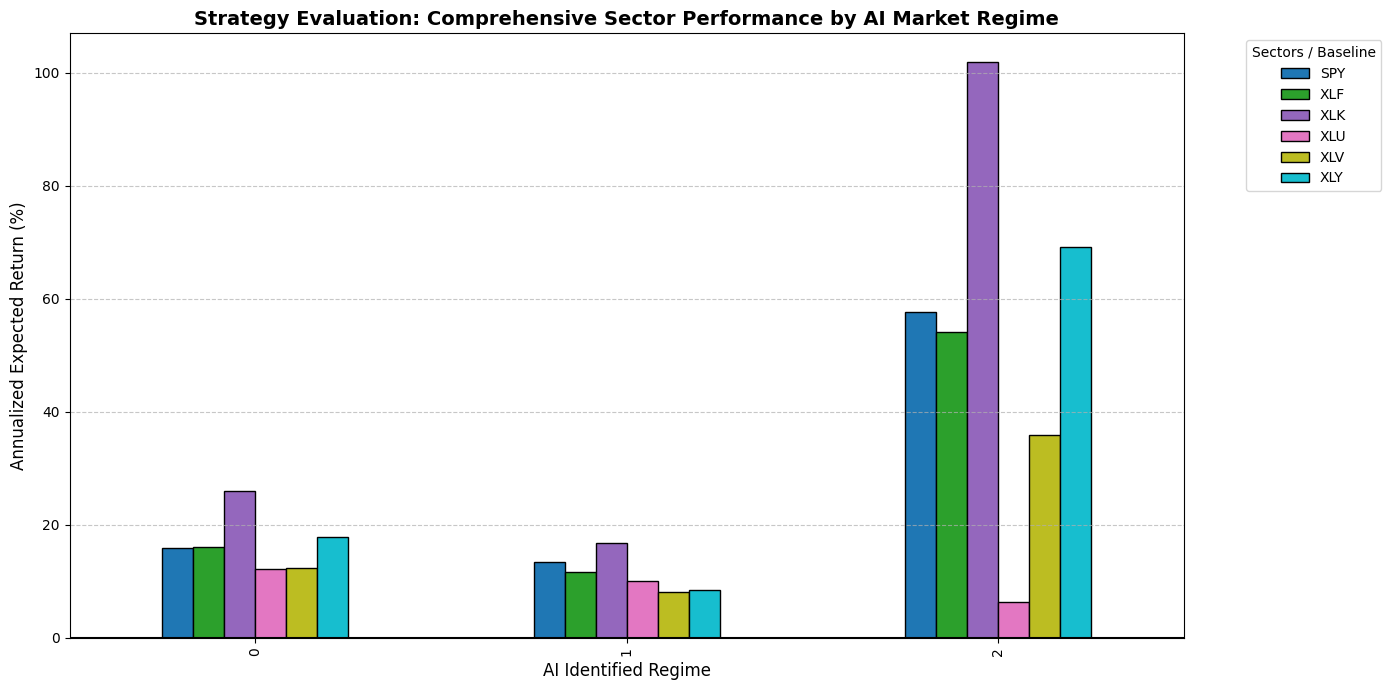

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- EVALUATING COMPREHENSIVE SECTOR ROTATION STRATEGY ---")

# THE FIX: Drop any columns that completely failed to download from Yahoo Finance
df_cleaned = df_cleaned.dropna(axis=1, how='all')

# 1. Dynamically find all valid asset columns that survived
price_columns = [col for col in df_cleaned.columns if col.startswith('Close_')]
assets = [col.split('_')[1] for col in price_columns]

# 2. Calculate Forward Returns for ALL valid assets in a loop
return_columns = []
for asset in assets:
    col_name = f'{asset}_Fwd_Return'
    df_cleaned[col_name] = df_cleaned[f'Close_{asset}'].pct_change().shift(-1)
    return_columns.append(col_name)

# THE FIX: Only drop rows where the *Returns* are missing (safely drops the final unknown day)
backtest_df = df_cleaned.dropna(subset=return_columns)

# 3. Group by Regime and calculate annualized returns
regime_performance = backtest_df.groupby('Regime')[return_columns].mean()
annualized_performance = regime_performance * 252 * 100 

# Clean up column names for the chart
annualized_performance.columns = assets

print("\n📈 Annualized Expected Return by Regime (%)")
display(annualized_performance.round(2))

# 4. Visualize the Comprehensive Rotation
plt.figure(figsize=(14, 7))
annualized_performance.plot(kind='bar', figsize=(14, 7), colormap='tab10', edgecolor='black')

plt.title('Strategy Evaluation: Comprehensive Sector Performance by AI Market Regime', fontsize=14, fontweight='bold')
plt.ylabel('Annualized Expected Return (%)', fontsize=12)
plt.xlabel('AI Identified Regime', fontsize=12)
plt.axhline(0, color='black', linewidth=1.5)
plt.legend(title='Sectors / Baseline', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() 
plt.show()